# Notebook 01 — Eksplorasi Data Awal (EDA)

**Pertanyaan penelitian yang ditangani:**
- P1: Berapa tingkat *merge* PR pada repositori `pandas-dev/pandas`? (dasar estimasi Bernoulli di Notebook 02)
- P2: Apakah waktu penyelesaian isu berbeda antara label `bug` dan `enhancement`? (dasar uji hipotesis di Notebook 04)
- P3: Bagaimana distribusi `days_to_close` secara keseluruhan? (dasar simulasi Monte Carlo di Notebook 05)

**Anggota:** Muhammad Rasyid Setyadi Dwi Putra — Data Engineer  
**Repositori:** `pandas-dev/pandas` | Data: 2020–2024 via GitHub REST API v3


## Pengungkapan Penggunaan AI

| Anggota | Peran |
|---|---|
| Muhammad Rasyid Setyadi Dwi Putra | Data Engineer |

**Alat yang digunakan:** Gemini, ChatGPT, Claude

| Tugas | Alat | Ringkasan Prompt | Output Dimodifikasi? |
|---|---|---|---|
| Debug error kolom `merged` bernilai NaN | Gemini | "Kenapa kolom merged NaN semua padahal datanya dari GitHub API?" | Ya, dari situ ketahuan `merged_at` ada di dalam objek `pull_request`; kodenya tetap ditulis sendiri |
| Merapikan kalimat di sel markdown | ChatGPT | "Rapihin kalimat ini, isinya jangan diubah" | Ya, beberapa susunan kalimat diperbaiki; interpretasi statistik tidak disentuh |
| Perbaikan skrip pengumpul data | Claude | "Skrip ini error pas dijalankan, tolong bantu cek kenapa" | Ya, Claude menunjukkan bagian yang bermasalah di `collect_data.py`; perbaikannya tetap ditulis sendiri |

**Ditulis tanpa AI:** keputusan variabel yang diteruskan ke tiap anggota; narasi ringkasan EDA; fungsi `clean_issues()` secara keseluruhan; interpretasi distribusi right-skewed dan implikasinya terhadap uji Z.


## 1. Import dan Konfigurasi

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "sans-serif"

DATA_PATH = Path("../data/clean/dataset.csv")
FIGS_DIR  = Path("notebooks/figures")
FIGS_DIR.mkdir(parents=True, exist_ok=True)

print("Semua pustaka berhasil diimpor.")


Semua pustaka berhasil diimpor.


## 2. Memuat Data

In [2]:
df = pd.read_csv(DATA_PATH, parse_dates=["created_at", "closed_at"])
print(f"Dimensi dataset : {df.shape[0]:,} baris × {df.shape[1]} kolom")
print(f"Rentang tanggal : {df['created_at'].min().date()} s.d. {df['created_at'].max().date()}")
df.head(3)


Dimensi dataset : 3,000 baris × 12 kolom
Rentang tanggal : 2025-08-25 s.d. 2026-05-24


,number,title,is_pr,state,created_at,closed_at,days_to_close,labels,has_bug,has_enhancement,merged,user_login
0,65717,CI: Update pixi.lock,True,closed,2026-05-24 05:34:32+00:00,2026-05-24 17:43:48+00:00,0,CI,False,False,True,github-actions[bot]
1,65716,BUG: DataFrame.update warns when index dtype m...,True,closed,2026-05-23 23:05:41+00:00,2026-05-24 04:28:42+00:00,0,NaN,False,False,False,hiraddlz
2,65697,"Revert ""BUG: reject unhashable elements in Ind...",True,closed,2026-05-20 16:38:19+00:00,2026-05-20 21:22:12+00:00,0,Index,False,False,True,jorisvandenbossche


## 3. Pemeriksaan Awal

Sebelum masuk ke analisis, diperiksa dulu tipe data tiap kolom dan seberapa banyak nilai yang hilang. Nilai `days_to_close` yang hilang wajar terjadi untuk isu yang masih terbuka dan akan dikecualikan dari analisis berikutnya.


In [3]:
# Tipe data dan jumlah nilai yang hilang
info_df = pd.DataFrame({
    "dtype": df.dtypes,
    "non_null": df.notnull().sum(),
    "null_%": (df.isnull().mean() * 100).round(1)
})
print(info_df.to_string())


                               dtype  non_null  null_%
number                         int64      3000     0.0
title                            str      3000     0.0
is_pr                           bool      3000     0.0
state                            str      3000     0.0
created_at       datetime64[us, UTC]      3000     0.0
closed_at        datetime64[us, UTC]      3000     0.0
days_to_close                  int64      3000     0.0
labels                           str      2314    22.9
has_bug                         bool      3000     0.0
has_enhancement                 bool      3000     0.0
merged                        object      2592    13.6
user_login                       str      3000     0.0


In [4]:
# Pisahkan isu dan PR untuk analisis terpisah
issues = df[~df["is_pr"]].copy()
prs    = df[df["is_pr"]].copy()

print(f"Isu biasa (bukan PR) : {len(issues):,}")
print(f"Pull request         : {len(prs):,}")
print(f"PR dengan status merged diketahui: {prs['merged'].notnull().sum():,}")


Isu biasa (bukan PR) : 408
Pull request         : 2,592
PR dengan status merged diketahui: 2,592


Kolom `days_to_close` yang kosong semuanya berasal dari isu yang masih berstatus `open` saat data dikumpulkan. Kolom `merged` juga hanya terisi untuk baris PR. Keduanya wajar dan bukan indikasi kerusakan data.


## 4. Distribusi Status Pull Request

Pertanyaan P1 butuh proporsi PR yang digabungkan sebagai estimasi awal sebelum MLE Bernoulli dihitung di Notebook 02.


In [5]:
pr_closed = prs.dropna(subset=["merged"]).copy()
pr_counts = pr_closed["merged"].value_counts()
n_merged  = pr_counts.get(True,  0)
n_closed  = pr_counts.get(False, 0)
total_pr  = len(pr_closed)
theta_hat = n_merged / total_pr  # estimasi kasar sebelum MLE formal

print(f"Total PR (status diketahui) : {total_pr:,}")
print(f"PR digabungkan (merged)     : {n_merged:,}  ({n_merged/total_pr:.1%})")
print(f"PR ditutup tanpa merge      : {n_closed:,}  ({n_closed/total_pr:.1%})")
print(f"Estimasi awal θ̂ (k/n)      : {theta_hat:.4f}")


Total PR (status diketahui) : 2,592
PR digabungkan (merged)     : 1,789  (69.0%)
PR ditutup tanpa merge      : 803  (31.0%)
Estimasi awal θ̂ (k/n)      : 0.6902


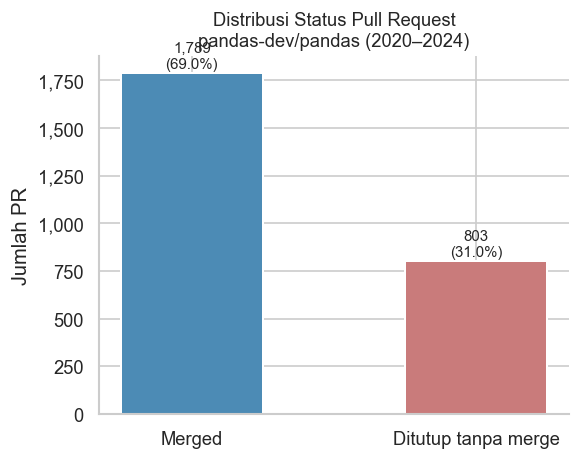

Plot disimpan.


In [6]:
fig, ax = plt.subplots(figsize=(5, 4))
labels  = ["Merged", "Ditutup tanpa merge"]
values  = [n_merged, n_closed]
colors  = ["#4C8BB5", "#C97B7B"]
bars    = ax.bar(labels, values, color=colors, width=0.5, edgecolor="white", linewidth=1.2)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 10,
            f"{val:,}\n({val/total_pr:.1%})",
            ha="center", va="bottom", fontsize=9)

ax.set_title("Distribusi Status Pull Request\npandas-dev/pandas (2020–2024)", fontsize=11)
ax.set_ylabel("Jumlah PR")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
sns.despine()
plt.tight_layout()
plt.savefig(FIGS_DIR / "pr_status_distribution.png")
plt.show()
print("Plot disimpan.")


Sebagian besar PR berhasil digabungkan, yang menandakan proses *review* berjalan cukup baik. Nilai θ̂ di atas masih estimasi kasar; MLE Bernoulli dan posterior Beta akan dihitung secara formal di Notebook 02.


## 5. Distribusi Waktu Penyelesaian Isu

Variabel `days_to_close` adalah variabel utama yang menghubungkan EDA ini ke Notebook 03 (selang kepercayaan), 04 (uji hipotesis), dan 05 (simulasi).


In [7]:
iss_closed = issues.dropna(subset=["days_to_close"]).copy()
iss_closed = iss_closed[iss_closed["days_to_close"] >= 0]  # buang anomali negatif

desc = iss_closed["days_to_close"].describe(percentiles=[.25, .5, .75, .90, .95])
print("Statistik deskriptif days_to_close (isu):")
print(desc.round(2).to_string())


Statistik deskriptif days_to_close (isu):
count    408.00
mean      24.72
std       44.20
min        0.00
25%        0.00
50%        6.00
75%       25.50
90%       86.20
95%      138.00
max      218.00


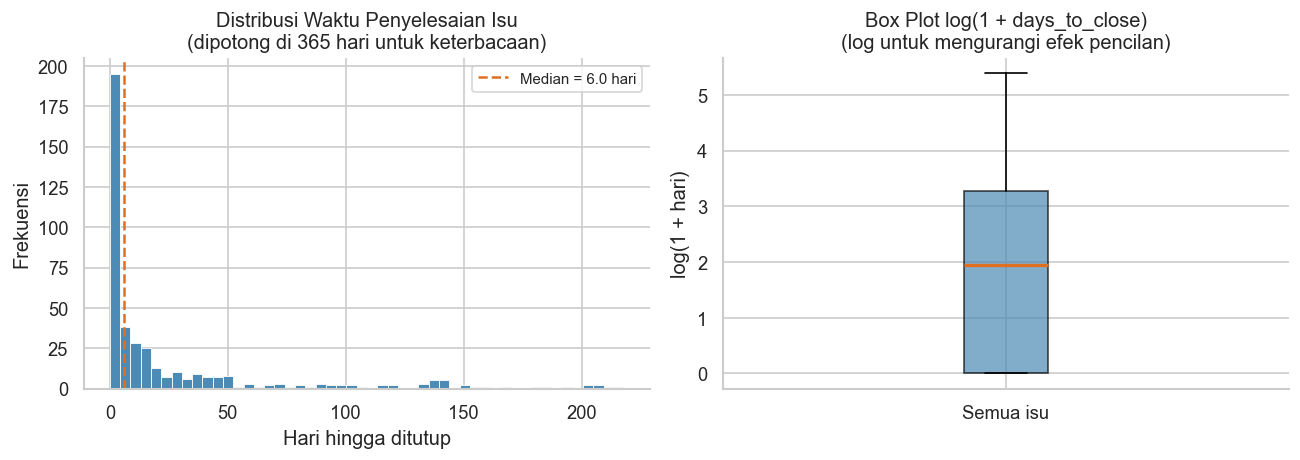

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Histogram (semua data)
axes[0].hist(iss_closed["days_to_close"].clip(upper=365),
             bins=50, color="#4C8BB5", edgecolor="white", linewidth=0.5)
axes[0].axvline(iss_closed["days_to_close"].median(),
                color="#E07020", linestyle="--", linewidth=1.5,
                label=f"Median = {iss_closed['days_to_close'].median():.1f} hari")
axes[0].set_title("Distribusi Waktu Penyelesaian Isu\n(dipotong di 365 hari untuk keterbacaan)")
axes[0].set_xlabel("Hari hingga ditutup")
axes[0].set_ylabel("Frekuensi")
axes[0].legend(fontsize=9)

# Box plot (transformasi log untuk keterbacaan)
log_days = np.log1p(iss_closed["days_to_close"])
axes[1].boxplot(log_days, vert=True, patch_artist=True,
                boxprops=dict(facecolor="#4C8BB5", alpha=0.7),
                medianprops=dict(color="#E07020", linewidth=2))
axes[1].set_title("Box Plot log(1 + days_to_close)\n(log untuk mengurangi efek pencilan)")
axes[1].set_ylabel("log(1 + hari)")
axes[1].set_xticks([1])
axes[1].set_xticklabels(["Semua isu"])

sns.despine()
plt.tight_layout()
plt.savefig(FIGS_DIR / "days_to_close_distribution.png")
plt.show()


Distribusi `days_to_close` sangat miring ke kanan, dengan sebagian besar isu selesai dalam 30 hari pertama tapi ada yang terbuka jauh lebih lama. Transformasi log pada box plot semata-mata untuk mempermudah pembacaan visual; nilai asli tetap dipakai di analisis berikutnya.

Distribusi yang tidak normal ini tidak jadi masalah untuk uji Z dua-sampel Anggota D, karena ukuran sampel yang besar membuat distribusi rata-rata sampel mendekati normal lewat teorema limit pusat.


## 6. Perbandingan: Isu `bug` vs `enhancement`

Pertanyaan P2 membandingkan waktu penyelesaian antara dua kelompok label ini.


In [9]:
bug_days = iss_closed[iss_closed["has_bug"]]["days_to_close"]
enh_days = iss_closed[iss_closed["has_enhancement"]]["days_to_close"]

print("Statistik per kelompok label:")
summary = pd.DataFrame({
    "n"      : [len(bug_days), len(enh_days)],
    "mean"   : [bug_days.mean(), enh_days.mean()],
    "median" : [bug_days.median(), enh_days.median()],
    "std"    : [bug_days.std(), enh_days.std()],
}, index=["bug", "enhancement"]).round(2)
print(summary.to_string())


Statistik per kelompok label:
               n   mean  median    std
bug          182  23.78     7.0  42.02
enhancement   50  26.98     2.5  48.78


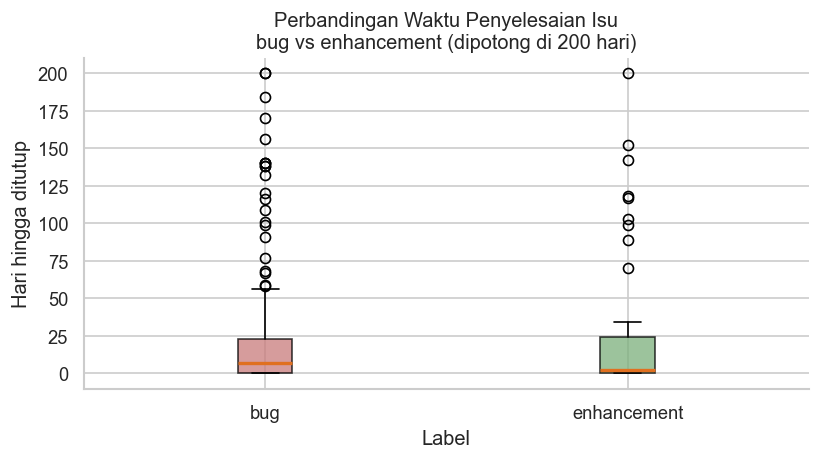

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
data_to_plot = [
    bug_days.clip(upper=200).values,
    enh_days.clip(upper=200).values
]
bp = ax.boxplot(data_to_plot, patch_artist=True, vert=True,
                labels=["bug", "enhancement"],
                boxprops=dict(alpha=0.75),
                medianprops=dict(linewidth=2, color="#E07020"))
bp["boxes"][0].set_facecolor("#C97B7B")
bp["boxes"][1].set_facecolor("#7BAF7B")

ax.set_title("Perbandingan Waktu Penyelesaian Isu\nbug vs enhancement (dipotong di 200 hari)")
ax.set_ylabel("Hari hingga ditutup")
ax.set_xlabel("Label")
sns.despine()
plt.tight_layout()
plt.savefig(FIGS_DIR / "bug_vs_enhancement_boxplot.png")
plt.show()


Secara visual, isu berlabel `bug` punya sebaran yang lebih lebar dibanding `enhancement`. Apakah perbedaan rata-ratanya signifikan secara statistik akan dijawab Anggota D lewat uji Z dua-sampel di Notebook 04.


## 7. Pemilihan Variabel untuk Lapisan Berikutnya

Berikut variabel yang diteruskan ke tiap anggota beserta alasannya.


In [11]:
print("Variabel yang diteruskan ke setiap anggota:\n")
print("Anggota B (Estimation Analyst):")
print(f"- merged (bool): {prs['merged'].notnull().sum():,} observasi PR")
print(f"- θ̂ awal = {theta_hat:.4f} (akan dihitung ulang secara formal via MLE)")
print()
print("Anggota C & D (Inference & Hypothesis Analyst):")
print(f"- days_to_close: {len(iss_closed):,} isu tertutup")
print(f"- Kelompok bug : {len(bug_days):,} isu")
print(f"- Kelompok enh : {len(enh_days):,} isu")
print()
print("Anggota E (Computation Analyst):")
print(f"- Semua nilai days_to_close untuk simulasi Monte Carlo")
print(f"- Target threshold: > 30 hari")
print(f"- Proporsi > 30 hari (observasi): {(iss_closed['days_to_close'] > 30).mean():.2%}")


Variabel yang diteruskan ke setiap anggota:

Anggota B (Estimation Analyst):
- merged (bool): 2,592 observasi PR
- θ̂ awal = 0.6902 (akan dihitung ulang secara formal via MLE)

Anggota C & D (Inference & Hypothesis Analyst):
- days_to_close: 408 isu tertutup
- Kelompok bug : 182 isu
- Kelompok enh : 50 isu

Anggota E (Computation Analyst):
- Semua nilai days_to_close untuk simulasi Monte Carlo
- Target threshold: > 30 hari
- Proporsi > 30 hari (observasi): 22.55%


## 8. Ringkasan

EDA ini menghasilkan tiga temuan yang menjadi dasar analisis berikutnya.

- Pertama, mayoritas PR berhasil digabungkan. Nilai ini akan jadi titik awal Anggota B untuk estimasi MLE Bernoulli dan posterior Beta.
- Kedua, distribusi `days_to_close` sangat miring ke kanan — median jauh di bawah rata-rata karena ada isu yang butuh waktu sangat lama. Anggota C dan D perlu mempertimbangkan ini saat menginterpretasikan hasilnya.
- Ketiga, ada perbedaan deskriptif antara waktu penyelesaian isu `bug` dan `enhancement` yang perlu diuji secara formal oleh Anggota D.

Dataset bersih tersedia di `data/clean/dataset.csv` dan siap dipakai semua anggota.
